In [1]:
import os
import pandas as pd

# Folder containing the Excel files
folder_path = "C:/Users/liujo/Documents/ESILV/NLP/data"

# Get all Excel files in the folder
excel_files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]

# Create an empty list to store data from each file
dataframes = []

# Loop through each file and read the data
for file in excel_files:
    file_path = os.path.join(folder_path, file)
    print(f"Reading file: {file}")
    
    # Read the Excel file
    try:
        data = pd.read_excel(file_path)
        data['source_file'] = file  # Add a column to track which file the data came from
        dataframes.append(data)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all the DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)

# Display the first few rows of the combined DataFrame
print(combined_df.head())

Reading file: avis_10_traduit.xlsx
Reading file: avis_11_traduit.xlsx
Reading file: avis_12_traduit.xlsx
Reading file: avis_13_traduit.xlsx
Reading file: avis_14_traduit.xlsx
Reading file: avis_15_traduit.xlsx
Reading file: avis_16_traduit.xlsx
Reading file: avis_17_traduit.xlsx
Reading file: avis_18_traduit.xlsx
Reading file: avis_19_traduit.xlsx
Reading file: avis_1_traduit.xlsx
Reading file: avis_20_traduit.xlsx
Reading file: avis_21_traduit.xlsx
Reading file: avis_22_traduit.xlsx
Reading file: avis_23_traduit.xlsx
Reading file: avis_24_traduit.xlsx
Reading file: avis_25_traduit.xlsx
Reading file: avis_26_traduit.xlsx
Reading file: avis_27_traduit.xlsx
Reading file: avis_28_traduit.xlsx
Reading file: avis_29_traduit.xlsx
Reading file: avis_2_traduit.xlsx
Reading file: avis_30_traduit.xlsx
Reading file: avis_31_traduit.xlsx
Reading file: avis_32_traduit.xlsx
Reading file: avis_33_traduit.xlsx
Reading file: avis_34_traduit.xlsx
Reading file: avis_35_traduit.xlsx
Reading file: avis_3_t

In [2]:
combined_df.shape

(34435, 12)

In [3]:
# Replace empty strings with NaN
combined_df.replace('', pd.NA, inplace=True)

In [4]:
missing_summary = combined_df.isnull().sum()
missing_summary

note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
source_file             0
dtype: int64

In [5]:
#Dropping Unnecessary Columns
columns_to_drop = ['avis_cor', 'avis_cor_en', 'source_file', 'date_publication', "date_exp"]
combined_df = combined_df.drop(columns=columns_to_drop, axis=1)

In [6]:
combined_df.head()

,note,auteur,avis,assureur,produit,type,avis_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,The person on the phone was clear and friendly...
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,"Satisfied.\n\nReactivity, simplicity. Attracti..."
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,"Insurer to flee, does not ensure its responsib..."
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,The GMF has been waiting for a water damage fo...
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,I am good with this insurance. She is practica...


In [7]:
# Drop rows where essential information like 'avis' (review) is missing
combined_df = combined_df.dropna(subset=['avis_en'])

In [8]:
missing_summary = combined_df.isnull().sum()
missing_summary

note        10330
auteur          1
avis            0
assureur        0
produit         0
type            0
avis_en         0
dtype: int64

In [9]:
unique_categories = combined_df['type'].unique()
unique_categories

array(['train', 'test'], dtype=object)

In [10]:
# Check for missing values in the 'note' column
missing_note_data = combined_df[combined_df['note'].isnull()]

# Verify if all missing 'note' values belong to the 'test' category in the 'type' column
missing_note_type_distribution = missing_note_data['type'].value_counts()

missing_note_type_distribution

#La ici, c'est pour voir si les notes vides c'est bien que pour le testing ou non, et on voit que oui, donc c'est bon

type
test    10330
Name: count, dtype: int64

In [11]:
# Define the text columns
text_columns = ['auteur', 'avis', 'assureur', 'produit', 'avis_en']

# Strip leading and trailing spaces
for col in text_columns:
    if col in combined_df.columns:
        combined_df[col] = combined_df[col].astype(str).str.strip()
        combined_df[col] = combined_df[col].str.replace('\n', ' ', regex=True)

combined_df.head()

#La c'est pour nettoyer les avis_en, pour enlever tous les trucs de latex qui servent à rien

,note,auteur,avis,assureur,produit,type,avis_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,The person on the phone was clear and friendly...
1,4.0,paul-a-122970,"Satisfait. Réactivité, simplicité. Prix attra...",APRIL Moto,moto,train,"Satisfied. Reactivity, simplicity. Attractive..."
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,"Insurer to flee, does not ensure its responsib..."
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,The GMF has been waiting for a water damage fo...
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,I am good with this insurance. She is practica...


In [23]:
loading_count = combined_df['avis_en'].str.contains("Loading...", na=False).sum()

loading_count

1104

In [25]:
# Remove rows where 'avis_en' contains "Loading..."
combined_df = combined_df[~combined_df['avis_en'].str.contains("Loading...", na=False)]

# Confirm the removal of rows with "Loading..."
remaining_loading_count = combined_df['avis_en'].str.contains("Loading...", na=False).sum()

remaining_loading_count

0

In [29]:
combined_df

,note,auteur,avis,assureur,produit,type,avis_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,The person on the phone was clear and friendly...
1,4.0,paul-a-122970,"Satisfait. Réactivité, simplicité. Prix attra...",APRIL Moto,moto,train,"Satisfied. Reactivity, simplicity. Attractive..."
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,"Insurer to flee, does not ensure its responsib..."
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,The GMF has been waiting for a water damage fo...
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,I am good with this insurance. She is practica...
...,...,...,...,...,...,...,...
34430,3.0,patrice-63215,POUR LE MOMENT JE SUIS SATISFAIT DE CETTE MUTU...,Santiane,sante,train,For the moment I am satisfied with this mutual
34431,5.0,benjamin-d-111262,Le service et l'accompagnement sont de très bo...,Zen'Up,credit,train,The service and support are of very good quali...
34432,1.0,geal-136804,La pire assurance dans laquelle j'ai été. Doub...,Active Assurances,auto,train,The worst insurance in which I was. Doubly of ...
34433,3.0,castanho-p-108077,Je suis satisfe. Le prix ça me convien. Pas ch...,L'olivier Assurance,auto,train,I am satisfied. The price suits me. Cheap. The...


In [19]:
from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')

# Preprocess and tokenize the text data
tokenized_text = combined_df['avis_en'].dropna().astype(str).apply(word_tokenize).tolist()

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=tokenized_text,
    vector_size=240,  # Embedding dimension
    window=5,         # Context window size
    min_count=6,      # Minimum word frequency
    sg=1,             # Skip-gram model (use sg=0 for CBOW)
    epochs=45        # Number of training epochs
)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\liujo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [21]:
print("Words similar to 'insurance':")
print(word2vec_model.wv.most_similar("insurance"))

print("Words similar to 'price':")
print(word2vec_model.wv.most_similar("price"))


print("Words similar to 'car':")
print(word2vec_model.wv.most_similar("car"))

Words similar to 'insurance':
[('insurer', 0.5166520476341248), ('assurance', 0.44652172923088074), ('Ensuring', 0.40757569670677185), ('denote', 0.4073370099067688), ('asurance', 0.4015839099884033), ('contract', 0.3881068229675293), ('mutual', 0.36353185772895813), ('motorists', 0.3591236472129822), ('insurances', 0.355315625667572), ('Ensured', 0.35060814023017883)]
Words similar to 'price':
[('prices', 0.6874347925186157), ('Price', 0.528694212436676), ('rates', 0.5208251476287842), ('/price', 0.5171657800674438), ('rate', 0.486671507358551), ('attractive', 0.4744120240211487), ('Prices', 0.4644964635372162), ('quality/price', 0.45808839797973633), ('prix', 0.4497876763343811), ('facilitity', 0.44599786400794983)]
Words similar to 'car':
[('vehicle', 0.7108598947525024), ('motorcycle', 0.5502802729606628), ('scooter', 0.5001124143600464), ('cars', 0.4767894446849823), ('vehicles', 0.43481335043907166), ('auto', 0.42886093258857727), ('CM', 0.4089130461215973), ('van', 0.40663632750

C:\Users\liujo\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\liujo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\liujo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\liujo\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\liujo\anaconda3\Lib\subprocess.py", line 1026, in __init__
    sel

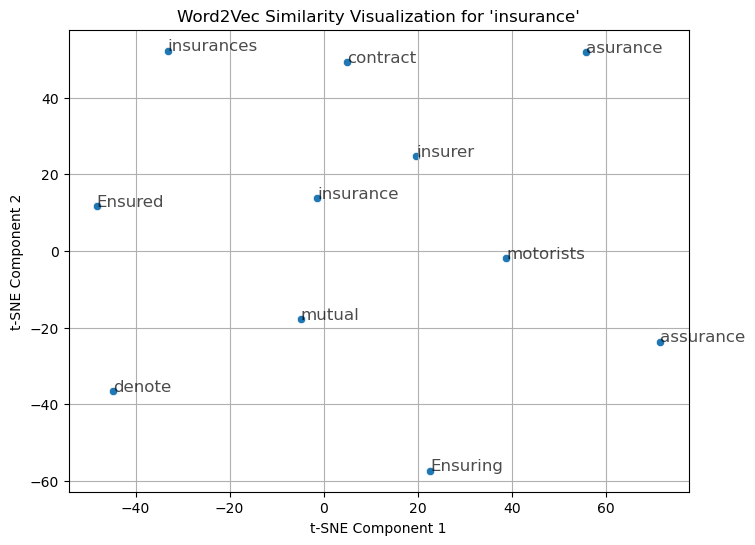

C:\Users\liujo\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\liujo\AppData\Local\Temp\ipykernel_16832\3945912773.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=word_embeddings_2d[:, 0], y=word_embeddings_2d[:, 1], palette='viridis')


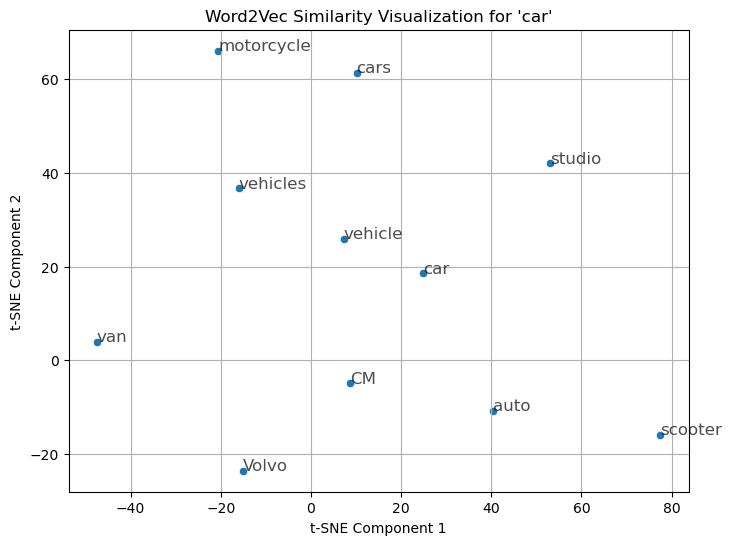

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np

# Word to analyze
word = ['insurance', 'car']
for target_word in word:
    # Get similar words to the target word
    similar_words = word2vec_model.wv.most_similar(target_word, topn=10)
    # Extract the similar words and their vectors
    words = [target_word] + [word for word, _ in similar_words]
    word_vectors = np.array([word2vec_model.wv[word] for word in words])
    tsne = TSNE(n_components=2, random_state=0, n_iter=300, perplexity=5)  # Lower perplexity
    word_embeddings_2d = tsne.fit_transform(word_vectors)

    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=word_embeddings_2d[:, 0], y=word_embeddings_2d[:, 1], palette='viridis')

    # Annotate the words in the plot
    for i, word in enumerate(words):
        plt.annotate(word, (word_embeddings_2d[i, 0], word_embeddings_2d[i, 1]), fontsize=12, alpha=0.7)

    # Title and labels
    plt.title(f"Word2Vec Similarity Visualization for '{target_word}'")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True)
    plt.show()

In [35]:
import numpy as np
from scipy.spatial.distance import cosine

# Step 1: Create embeddings for all reviews by averaging word vectors
def get_average_word_vector(text, model):
    tokens = word_tokenize(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)  # Fallback for empty tokens

# Generate embeddings for the reviews
combined_df['embedding'] = combined_df['avis_en'].dropna().astype(str).apply(
    lambda x: get_average_word_vector(x, word2vec_model)
)

# Step 2: Semantic Search Function
def semantic_search_word2vec(query, top_n=5):
    # Generate embedding for the query
    query_embedding = get_average_word_vector(query, word2vec_model)
    
    # Calculate cosine similarity
    combined_df['similarity'] = combined_df['embedding'].apply(
        lambda emb: 1 - cosine(query_embedding, emb) if np.linalg.norm(emb) > 0 else 0
    )
    
    # Get top n results
    top_results = combined_df.sort_values(by='similarity', ascending=False).head(top_n)
    return top_results[['avis_en', 'similarity']]

# Example Query
query = "bad customer service"
results = semantic_search_word2vec(query, top_n=5)

# Display Results
print("Semantic Search Results:")
for i, row in results.iterrows():
    print(f"Result {i + 1}:")
    print(f"Text: {row['avis_en']}")
    print(f"Similarity Score: {row['similarity']:.4f}\n")

Semantic Search Results:
Result 3773:
Text: very bad customer service
Similarity Score: 0.9474

Result 13603:
Text: Very bad service
Similarity Score: 0.8305

Result 24821:
Text: Very bad service
Similarity Score: 0.8305

Result 12966:
Text: Very bad phone service
Similarity Score: 0.7970

Result 26119:
Text: Latable customer service
Similarity Score: 0.7708



In [114]:
data = combined_df

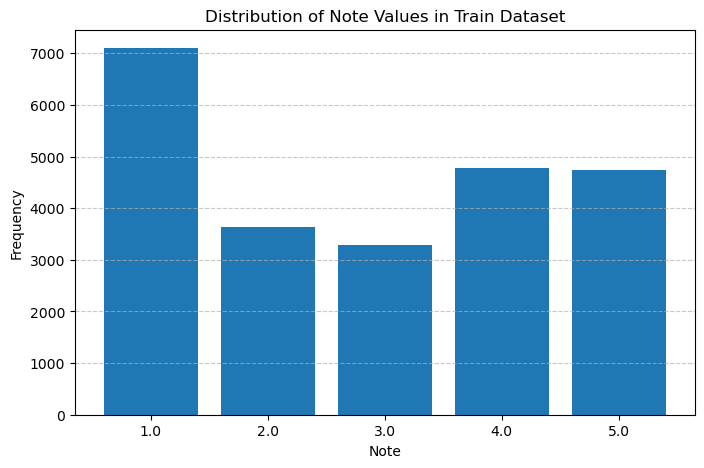

In [115]:
import matplotlib.pyplot as plt

# Filter for the train dataset where 'note' values are available
train_data = data[data['type'] == 'train']

# Plot the distribution of 'note' values
plt.figure(figsize=(8, 5))
train_data['note'].value_counts().sort_index().plot(kind='bar', width=0.8)
plt.title('Distribution of Note Values in Train Dataset')
plt.xlabel('Note')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

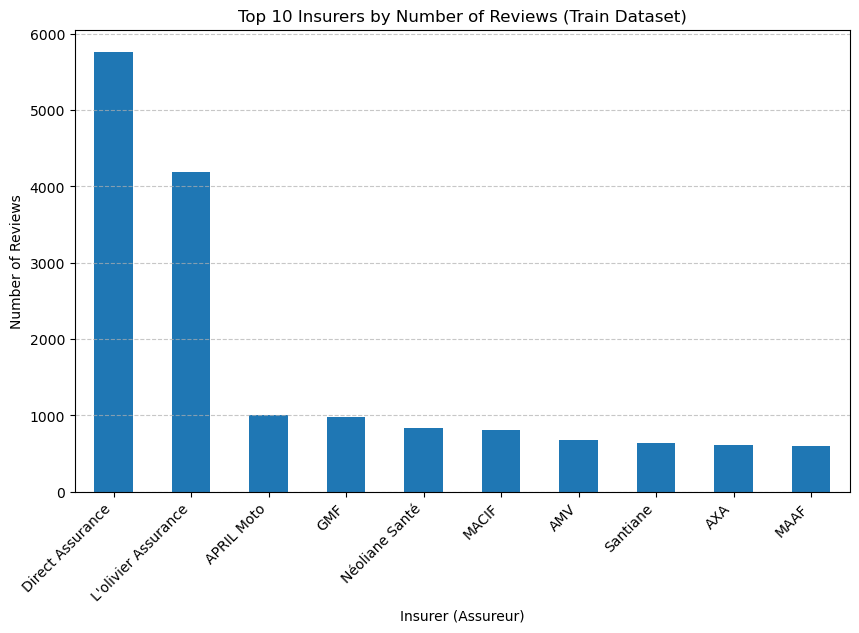

In [116]:
# Top insurers by the number of reviews
top_insurers = train_data['assureur'].value_counts().head(10)

# Plot the top insurers
plt.figure(figsize=(10, 6))
top_insurers.plot(kind='bar')
plt.title('Top 10 Insurers by Number of Reviews (Train Dataset)')
plt.xlabel('Insurer (Assureur)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

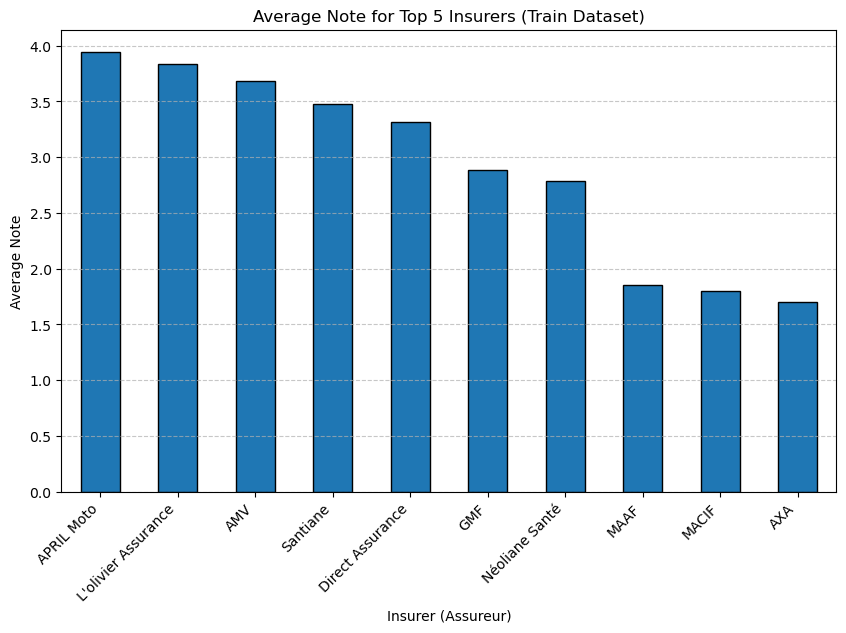

In [117]:
# Calculate the average note for the top 5 insurers based on review counts
top_10_insurers = train_data['assureur'].value_counts().head(10).index
average_note_top_insurers = train_data[train_data['assureur'].isin(top_10_insurers)].groupby('assureur')['note'].mean()

# Plot the average note for the top 5 insurers
plt.figure(figsize=(10, 6))
average_note_top_insurers.sort_values(ascending=False).plot(kind='bar', edgecolor='black')
plt.title('Average Note for Top 5 Insurers (Train Dataset)')
plt.xlabel('Insurer (Assureur)')
plt.ylabel('Average Note')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

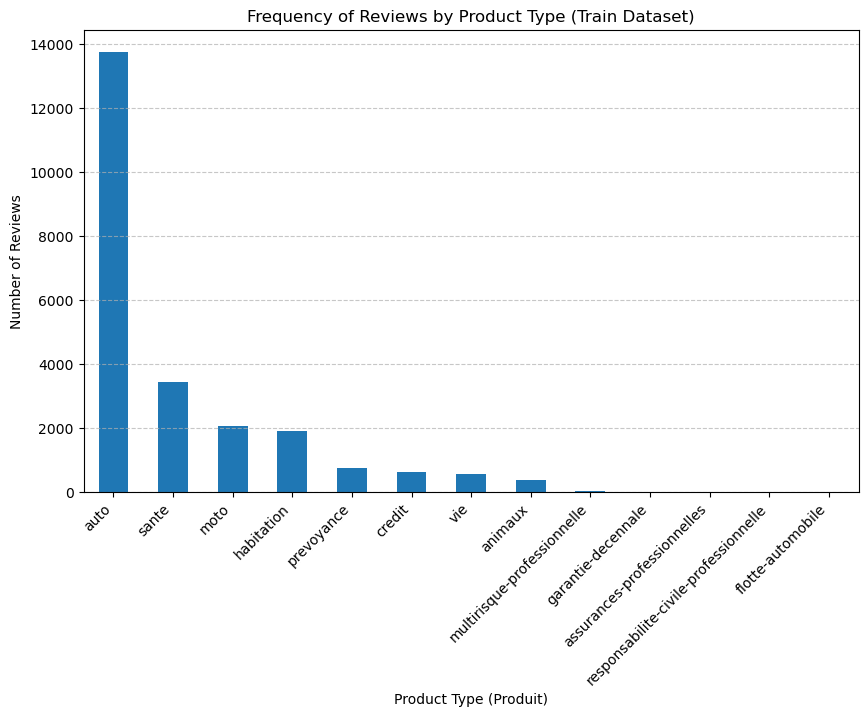

In [118]:
# Frequency of reviews by product type
product_frequency = train_data['produit'].value_counts()

# Plot the frequency of reviews by product type
plt.figure(figsize=(10, 6))
product_frequency.plot(kind='bar')
plt.title('Frequency of Reviews by Product Type (Train Dataset)')
plt.xlabel('Product Type (Produit)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

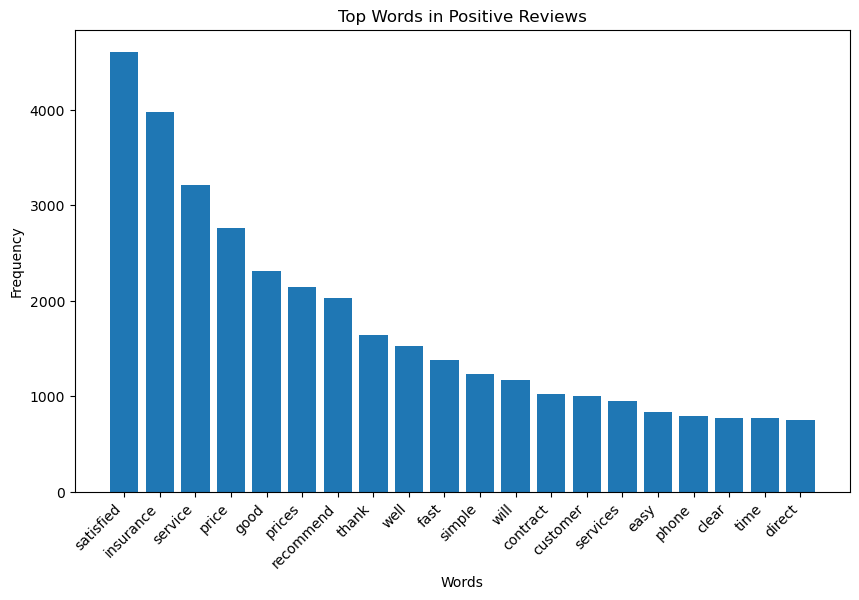

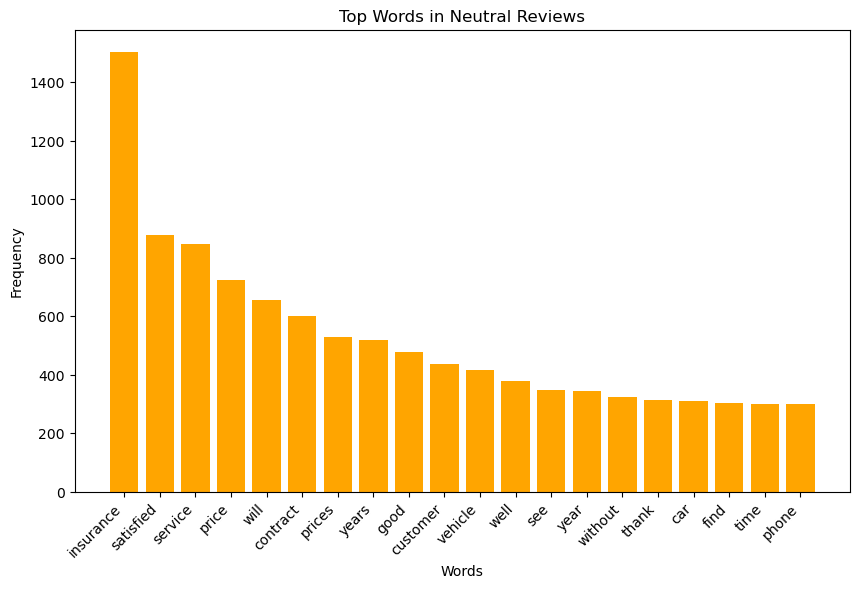

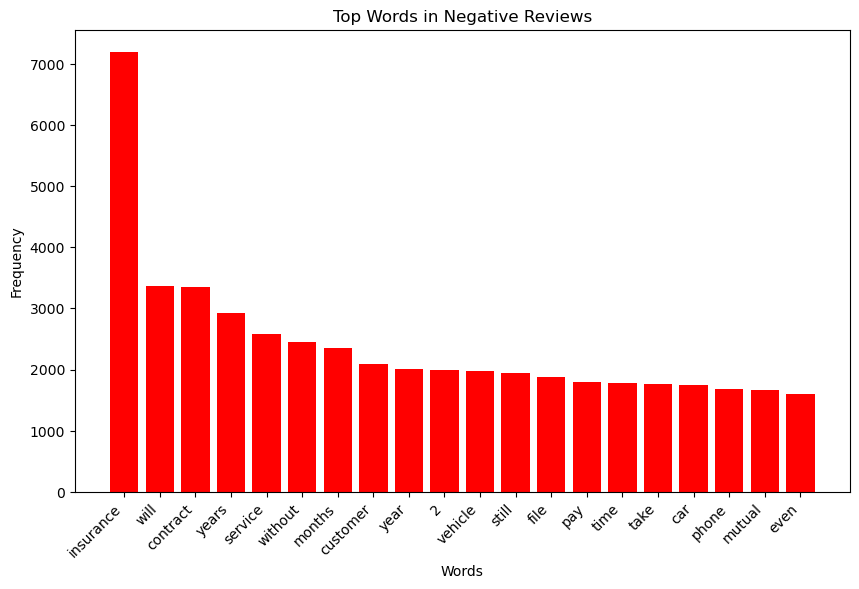

In [120]:
from collections import Counter
from wordcloud import STOPWORDS
import string

# Define positive and negative reviews
positive_reviews = train_data[train_data['note'] >= 4]['avis_en']
neutral_reviews = train_data[train_data['note'] == 3]['avis_en']
negative_reviews = train_data[train_data['note'] <= 2]['avis_en']

# Function to process text and count word frequencies
def get_word_frequencies(text_series):
    stopwords = set(STOPWORDS)
    all_text = " ".join(text_series.dropna()).lower()
    all_text = all_text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = all_text.split()
    words = [word for word in words if word not in stopwords]  # Remove stopwords
    return Counter(words)

# Get word frequencies for positive and negative reviews
positive_word_freq = get_word_frequencies(positive_reviews)
neutral_word_freq = get_word_frequencies(neutral_reviews)
negative_word_freq = get_word_frequencies(negative_reviews)

# Get the top 20 most common words for each
top_positive_words = positive_word_freq.most_common(20)
top_neutral_words = neutral_word_freq.most_common(20)
top_negative_words = negative_word_freq.most_common(20)

# Plot top words for positive reviews
positive_words, positive_counts = zip(*top_positive_words)
plt.figure(figsize=(10, 6))
plt.bar(positive_words, positive_counts)
plt.title('Top Words in Positive Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot top words for neutral reviews
neutral_words, neutral_counts = zip(*top_neutral_words)
plt.figure(figsize=(10, 6))
plt.bar(neutral_words, neutral_counts, color='orange')
plt.title('Top Words in Neutral Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot top words for negative reviews
negative_words, negative_counts = zip(*top_negative_words)
plt.figure(figsize=(10, 6))
plt.bar(negative_words, negative_counts, color='red')
plt.title('Top Words in Negative Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Step 1: Preprocess the data
# Filter the dataset to include only necessary columns for modeling
model_data = train_data[['avis_en', 'note']].dropna()

# Encode the 'note' column as a categorical target for classification
label_encoder = LabelEncoder()
model_data['note'] = label_encoder.fit_transform(model_data['note'])

# Step 2: Split the data into training and testing sets
X = model_data['avis_en']  # Features (text data)
y = model_data['note']     # Target (encoded notes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Vectorize the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Confirm shapes of the vectorized data
X_train_tfidf.shape, X_test_tfidf.shape


((18838, 5000), (4710, 5000))

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 4: Train a Random Forest Classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_tfidf, y_train)

# Step 5: Make predictions on the test set
y_pred = classifier.predict(X_test_tfidf)

# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_report_output = classification_report(y_test, y_pred)
confusion_matrix_output = confusion_matrix(y_test, y_pred)

In [123]:
print(accuracy)
print(classification_report_output)
print(confusion_matrix_output)

0.49660297239915074
              precision    recall  f1-score   support

           0       0.54      0.96      0.69      1420
           1       0.42      0.02      0.04       728
           2       0.32      0.04      0.08       659
           3       0.40      0.40      0.40       954
           4       0.49      0.58      0.53       949

    accuracy                           0.50      4710
   macro avg       0.44      0.40      0.35      4710
weighted avg       0.45      0.50      0.41      4710

[[1360    8    6   30   16]
 [ 636   16   20   35   21]
 [ 294    5   29  191  140]
 [ 136    6   27  381  404]
 [  72    3    8  313  553]]


In [124]:
# Step 1: Prepare the dataset for sentiment classification
# Define sentiment labels
train_data['sentiment'] = train_data['note'].apply(
    lambda x: 'positive' if x >= 4 else 'neutral' if x == 3 else 'negative'
)

# Step 2: Split the dataset
X_sentiment = train_data['avis_en']  # Features
y_sentiment = train_data['sentiment']  # Target

# Split into training and testing sets
X_train_sent, X_test_sent, y_train_sent, y_test_sent = train_test_split(
    X_sentiment, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

# Step 3: Vectorize the text using TF-IDF
X_train_sent_tfidf = tfidf_vectorizer.fit_transform(X_train_sent)
X_test_sent_tfidf = tfidf_vectorizer.transform(X_test_sent)

# Step 4: Train a Logistic Regression model for classification
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=500, random_state=42)
logistic_model.fit(X_train_sent_tfidf, y_train_sent)

# Step 5: Evaluate the model
y_pred_sentiment = logistic_model.predict(X_test_sent_tfidf)

# Classification report
classification_report_sentiment = classification_report(y_test_sent, y_pred_sentiment)
accuracy_sentiment = accuracy_score(y_test_sent, y_pred_sentiment)


C:\Users\liujo\AppData\Local\Temp\ipykernel_18352\2384185581.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['sentiment'] = train_data['note'].apply(


In [125]:
print(accuracy_sentiment)
print(classification_report_sentiment)

0.8016985138004247
              precision    recall  f1-score   support

    negative       0.82      0.95      0.88      2148
     neutral       0.33      0.07      0.12       659
    positive       0.81      0.89      0.85      1903

    accuracy                           0.80      4710
   macro avg       0.65      0.64      0.62      4710
weighted avg       0.75      0.80      0.76      4710



In [126]:
# Re-check the new_data for rows labeled as 'test' with missing 'note' values
test_data = data[data['type'] == 'test']
test_data_missing_note = test_data[test_data['note'].isnull()]

# Count the number of rows with missing 'note' in test data
missing_test_notes_count_new = test_data_missing_note.shape[0]

missing_test_notes_count_new

9781

In [127]:
# Step 1: Vectorize the text content of the missing test data
test_data_tfidf = tfidf_vectorizer.transform(test_data_missing_note['avis_en'])

# Step 2: Predict sentiment for the missing test data
test_data_missing_note['predicted_sentiment'] = logistic_model.predict(test_data_tfidf)

# Redefine the sentiment-to-note mapping
sentiment_to_note = {
    'positive': 4,
    'neutral': 3,
    'negative': 2
}

# Step 3: Map predicted sentiment to note values
test_data_missing_note['predicted_note'] = test_data_missing_note['predicted_sentiment'].map(sentiment_to_note)

# Step 4: Fill the missing notes in the original new_data dataset
data.loc[test_data_missing_note.index, 'note'] = test_data_missing_note['predicted_note']

# Display a sample of the updated test data with filled 'note' values
test_data_missing_note[['note', 'auteur', 'avis', 'assureur', 'avis_en', 'predicted_sentiment', 'predicted_note']]

#j'ai choisi de predire avec le modele de sentiment parce qu'il a un meilleur accuracy, de meilleur perfomance 

,note,auteur,avis,assureur,avis_en,predicted_sentiment,predicted_note
16104,NaN,lognos-d-139728,Satisfait des tarif et rapide j'attends de voi...,L'olivier Assurance,Satisfied with the price and fast I expect to ...,positive,4
16106,NaN,rozgonyi-o-139704,L’assurance Olivier est une très bonne assuran...,L'olivier Assurance,Olivier insurance is a very good insurance I a...,positive,4
16108,NaN,damis-s-139693,le prix est attractif par rapport à ma situati...,L'olivier Assurance,The price is attractive compared to my situati...,positive,4
16111,NaN,thiery-l-139681,"Je suis satisfaite de vos services, facile d'u...",L'olivier Assurance,"I am satisfied with your services, easy to use...",positive,4
16112,NaN,royet-j-139672,Je suis satisfait du service et de la proposit...,L'olivier Assurance,I am satisfied with the service and the commer...,positive,4
...,...,...,...,...,...,...,...
27430,NaN,mamybouly-129360,"Bonjour, j'ai une mauvaise expérience avec la ...",Sma,"Hello, I have a bad experience with the Socoba...",negative,2
27431,NaN,tarti-88637,Entreprise très impactée par le covid- secteur...,Allianz,Company very impacted by the covid- event sect...,negative,2
27432,NaN,victor-109599,"Suite a un cambriolage le 22/01/2021, je suis ...",Allianz,"Following a burglary on 01/22/2021, I am still...",negative,2
27433,NaN,lkio-110907,"Bonjour, Je constate qu'entre le moment de ma...",Generali,"Hello, I note that between the time of my req...",negative,2
